# Obscene Hand Sign Censorship

![banner](./docs/assets/censorship.png)

This notebook detects middle finger gestures in images and censors them by drawing a black rectangle over the gesture.

## Pipeline

**Stage 1 — MediaPipe Hand Landmark Detection (Neural Network #1)**  
MediaPipe Hands is a two-stage deep learning pipeline:
- A **palm detection CNN** (BlazePalm) finds the hand bounding box
- A **hand landmark regression network** predicts 21 3D keypoints from the cropped hand

This gives us accurate joint positions for every finger — no training data needed for this step.

**Stage 2 — Gesture Classification (Neural Network #2)**  
We extract 5 features (one extension ratio per finger) from the MediaPipe landmarks and train a small Keras MLP to classify whether the hand is making the middle finger gesture.

**Stage 3 — Censorship**  
OpenCV draws a filled black rectangle over the middle finger area.

## 1. Setup

In [14]:
import os
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

print(f"TensorFlow: {tf.__version__}")
print(f"MediaPipe:  {mp.__version__}")
print(f"OpenCV:     {cv2.__version__}")

TensorFlow: 2.21.0
MediaPipe:  0.10.33
OpenCV:     4.13.0


## 2. Load Image

Place your test image in `./data/` and update `IMAGE_PATH` below.  
The image should contain a hand making (or not making) the middle finger gesture.

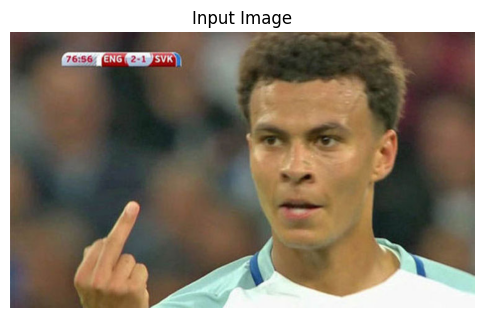

Image shape: (445, 750, 3)


In [15]:
IMAGE_PATH = "./data/hand_gesture.jpg"

img_bgr = cv2.imread(IMAGE_PATH)
if img_bgr is None:
    raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(img_rgb)
plt.axis("off")
plt.title("Input Image")
plt.show()

print(f"Image shape: {img_rgb.shape}")

## 3. MediaPipe Hand Landmark Detection

MediaPipe returns up to `max_num_hands` detected hands, each with 21 landmarks.
Landmark coordinates are **normalized** to [0, 1] relative to the image dimensions.

```
Wrist: 0
Thumb:  1 (CMC)  2 (MCP)  3 (IP)   4 (TIP)
Index:  5 (MCP)  6 (PIP)  7 (DIP)  8 (TIP)
Middle: 9 (MCP) 10 (PIP) 11 (DIP) 12 (TIP)
Ring:  13 (MCP) 14 (PIP) 15 (DIP) 16 (TIP)
Pinky: 17 (MCP) 18 (PIP) 19 (DIP) 20 (TIP)
```

In [16]:
MODEL_PATH = "./models/hand_landmarker.task"
os.makedirs(os.path.dirname(MODEL_PATH), exist_ok=True)

if not os.path.exists(MODEL_PATH):
    import urllib.request
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/latest/hand_landmarker.task"
    print("Downloading hand landmarker model...")
    urllib.request.urlretrieve(url, MODEL_PATH)
    print("Done.")

from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

base_options = mp_python.BaseOptions(model_asset_path=MODEL_PATH)
options = mp_vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.5,
)
detector = mp_vision.HandLandmarker.create_from_options(options)

mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
results = detector.detect(mp_image)

num_hands = len(results.hand_landmarks)
print(f"Detected {num_hands} hand(s)")

I0000 00:00:1774372257.729236   72237 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1774372257.795543   72249 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 Mesa 25.0.7-0ubuntu0.24.04.2), renderer: Mesa Intel(R) UHD Graphics 620 (KBL GT2)
W0000 00:00:1774372257.974391   72240 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774372258.132060   72246 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Detected 1 hand(s)


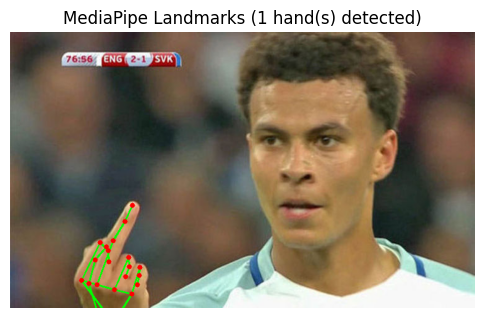

In [17]:
# Visualize detected landmarks using OpenCV (mp.solutions.drawing_utils removed in 0.10+)
HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (5,9),(9,10),(10,11),(11,12),
    (9,13),(13,14),(14,15),(15,16),
    (13,17),(17,18),(18,19),(19,20),
    (0,17),
]

img_landmarks = img_rgb.copy()
h, w = img_landmarks.shape[:2]

for hand_landmarks in results.hand_landmarks:
    for start, end in HAND_CONNECTIONS:
        x1, y1 = int(hand_landmarks[start].x * w), int(hand_landmarks[start].y * h)
        x2, y2 = int(hand_landmarks[end].x * w), int(hand_landmarks[end].y * h)
        cv2.line(img_landmarks, (x1, y1), (x2, y2), (0, 255, 0), 2)
    for lm in hand_landmarks:
        cx, cy = int(lm.x * w), int(lm.y * h)
        cv2.circle(img_landmarks, (cx, cy), 4, (255, 0, 0), -1)

plt.figure(figsize=(6, 6))
plt.imshow(img_landmarks)
plt.axis("off")
plt.title(f"MediaPipe Landmarks ({num_hands} hand(s) detected)")
plt.show()

## 4. Feature Engineering

From the 21 landmarks we compute **5 finger extension ratios** — one per finger.

$$\text{extension}_f = \frac{\text{MCP}_y - \text{TIP}_y}{\text{hand height}}$$

In image coordinates y increases downward, so:
- **Positive value** → finger is **extended** (tip is higher than MCP)
- **Negative / near-zero** → finger is **curled**

Dividing by hand height makes the feature scale-invariant.

In [18]:
# (MCP index, TIP index) for each finger
FINGER_JOINTS = {
    "thumb":  (2,  4),
    "index":  (5,  8),
    "middle": (9,  12),
    "ring":   (13, 16),
    "pinky":  (17, 20),
}


def extract_features(hand_landmarks):
    """Return a 5-element array of finger extension ratios.

    hand_landmarks: List[NormalizedLandmark] from the Tasks API
    """
    lm = hand_landmarks  # plain list — lm[i].x / lm[i].y / lm[i].z
    hand_height = max(l.y for l in lm) - min(l.y for l in lm)
    hand_height = max(hand_height, 1e-6)

    features = []
    for mcp_idx, tip_idx in FINGER_JOINTS.values():
        extension = (lm[mcp_idx].y - lm[tip_idx].y) / hand_height
        features.append(extension)

    return np.array(features, dtype=np.float32)

In [19]:
# Extract and display features for each detected hand
if results.hand_landmarks:
    for i, hand_landmarks in enumerate(results.hand_landmarks):
        features = extract_features(hand_landmarks)
        print(f"Hand {i + 1} feature vector:")
        for name, value in zip(FINGER_JOINTS.keys(), features):
            bar = "#" * int(max(0, value) * 30)
            print(f"  {name:6s}: {value:+.3f}  {bar}")
        print()
else:
    print("No hands detected — cannot extract features.")

Hand 1 feature vector:
  thumb : +0.309  #########
  index : +0.155  ####
  middle: +0.670  ####################
  ring  : +0.108  ###
  pinky : +0.077  ##



## 5. Rule-Based Classifier (Baseline)

A middle finger gesture ("flipping the bird") satisfies:
- Middle finger is **extended** (ratio > threshold)
- Index, ring, and pinky fingers are **curled** (ratio < threshold)
- Thumb position is ignored — it varies too much to be useful here

This acts as a simple baseline to compare against the neural network — no training required.

In [20]:
def is_middle_finger_rule_based(features, threshold=0.3):
    """Detect middle finger gesture using geometric rules.

    features: array [thumb, index, middle, ring, pinky] extension ratios
    Returns: (detected: bool, reason: str)
    """
    _thumb, index_ext, middle_ext, ring_ext, pinky_ext = features

    middle_up  = middle_ext > threshold
    index_down = index_ext  < threshold
    ring_down  = ring_ext   < threshold
    pinky_down = pinky_ext  < threshold

    detected = middle_up and index_down and ring_down and pinky_down
    reason = (
        f"middle={'up' if middle_up else 'down'}, "
        f"index={'down' if index_down else 'UP'}, "
        f"ring={'down' if ring_down else 'UP'}, "
        f"pinky={'down' if pinky_down else 'UP'}"
    )
    return detected, reason


# Test on detected hands
if results.hand_landmarks:
    for i, hand_landmarks in enumerate(results.hand_landmarks):
        features = extract_features(hand_landmarks)
        detected, reason = is_middle_finger_rule_based(features)
        print(f"Hand {i + 1} — Rule-based: {'DETECTED' if detected else 'not detected'} ({reason})")

Hand 1 — Rule-based: DETECTED (middle=up, index=down, ring=down, pinky=down)


## 6. Keras MLP Classifier

We train a small feedforward neural network on the 5-feature vectors.

### Training Data

Since I didn't have a labelled dataset of hand gesture images, I generated synthetic training data using the same geometric rules as the rule-based classifier, with some added Gaussian noise to make the training samples more realistic.

To train on real data, replace `generate_synthetic_data()` with a function that:
1. Downloads the [HaGRID dataset](https://github.com/hukenovs/hagrid) (`middle_finger` class)
2. Runs MediaPipe on each image to extract landmarks
3. Calls `extract_features()` and saves to a CSV
4. Loads the CSV here

In [21]:
def generate_synthetic_data(n_samples=2000, noise_std=0.08, seed=42):
    """Generate synthetic hand gesture feature vectors.

    Features: [thumb, index, middle, ring, pinky] extension ratios.
    Label 1 = middle finger gesture, 0 = other.
    """
    rng = np.random.default_rng(seed)
    X, y = [], []

    half = n_samples // 2

    # --- Positive class: middle up, others down ---
    for _ in range(half):
        thumb  = rng.uniform(-0.1, 0.4)   # thumb position varies
        index  = rng.uniform(-0.2, 0.15)  # curled
        middle = rng.uniform(0.45, 1.0)   # extended
        ring   = rng.uniform(-0.2, 0.15)  # curled
        pinky  = rng.uniform(-0.2, 0.15)  # curled
        feat = np.array([thumb, index, middle, ring, pinky], dtype=np.float32)
        feat += rng.normal(0, noise_std, size=5).astype(np.float32)
        X.append(feat)
        y.append(1)

    # --- Negative class: various other gestures ---
    for _ in range(half):
        feat = rng.uniform(-0.3, 1.0, size=5).astype(np.float32)
        feat[2] = rng.uniform(-0.3, 0.28)  # middle NOT extended
        feat += rng.normal(0, noise_std * 0.5, size=5).astype(np.float32)
        X.append(feat)
        y.append(0)

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    # Shuffle
    idx = rng.permutation(len(X))
    return X[idx], y[idx]


X_train, y_train = generate_synthetic_data()
print(f"Dataset shape : {X_train.shape}")
print(f"Positive class: {int(y_train.sum())} samples ({y_train.mean():.0%})")
print(f"Negative class: {int((1 - y_train).sum())} samples")

Dataset shape : (2000, 5)
Positive class: 1000 samples (50%)
Negative class: 1000 samples


In [22]:
tf.random.set_seed(42)

model = keras.Sequential(
    [
        keras.layers.Input(shape=(5,), name="landmark_features"),
        keras.layers.Dense(32, activation="relu"),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(16, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid", name="gesture_probability"),
    ],
    name="gesture_classifier",
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()

history = model.fit(
    X_train,
    y_train,
    epochs=40,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
)

Model: "gesture_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gesture_probability (Dense)     │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 737 (2.88 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8462 - loss: 0.5996 - val_accuracy: 0.9800 - val_loss: 0.4752
Epoch 2/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9656 - loss: 0.3695 - val_accuracy: 0.9850 - val_loss: 0.2211
Epoch 3/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9787 - loss: 0.1710 - val_accuracy: 0.9900 - val_loss: 0.0941
Epoch 4/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9850 - loss: 0.0913 - val_accuracy: 0.9950 - val_loss: 0.0534
Epoch 5/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9881 - loss: 0.0583 - val_accuracy: 0.9950 - val_loss: 0.0365
Epoch 6/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9894 - loss: 0.0445 - val_accuracy: 0.9950 - val_loss: 0.0283
Epoch 7/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9906 - loss: 0.0378 - val_accuracy: 0.9950 - val_loss: 0.0234
Epoch 8/40
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9925 - loss: 0.0305 - val_accuracy: 0.9950 - val_loss

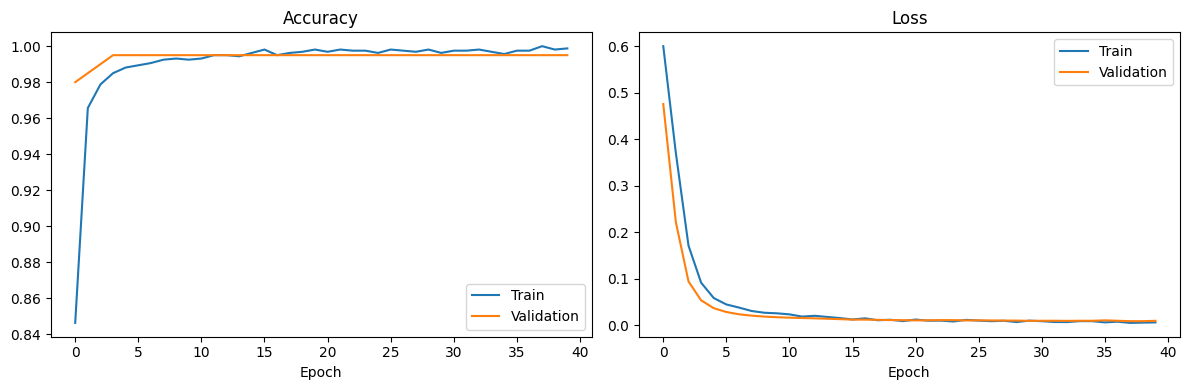

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"],     label="Train")
axes[0].plot(history.history["val_accuracy"], label="Validation")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Train")
axes[1].plot(history.history["val_loss"], label="Validation")
axes[1].set_title("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [24]:
def is_middle_finger_nn(features, threshold=0.5):
    """Detect middle finger gesture using the trained Keras MLP.

    Returns: (detected: bool, confidence: float)
    """
    prob = float(model.predict(features[np.newaxis, :], verbose=0)[0, 0])
    return prob > threshold, prob

## 7. Censorship

When a middle finger gesture is detected (by either classifier), we:
1. Compute the bounding box of landmarks 9–12 (middle finger MCP → TIP)
2. Add 3% padding on each side
3. Draw a filled black rectangle over that region

In [25]:
def get_middle_finger_bbox(hand_landmarks, image_shape, padding=0.03):
    """Return (x1, y1, x2, y2) pixel coordinates covering the middle finger.

    hand_landmarks: List[NormalizedLandmark] from the Tasks API
    """
    h, w = image_shape[:2]
    lm = hand_landmarks  # plain list

    # Landmarks 9–12: MCP, PIP, DIP, TIP of the middle finger
    middle_idxs = [9, 10, 11, 12]
    xs = [lm[i].x for i in middle_idxs]
    ys = [lm[i].y for i in middle_idxs]

    x1 = max(0, int((min(xs) - padding) * w))
    y1 = max(0, int((min(ys) - padding) * h))
    x2 = min(w, int((max(xs) + padding) * w))
    y2 = min(h, int((max(ys) + padding) * h))

    return x1, y1, x2, y2

Hand 1
  Rule-based : DETECTED (middle=up, index=down, ring=down, pinky=down)
  Keras MLP  : DETECTED (confidence 100.0%)
  Censored   : rectangle (118,266) → (220,421)



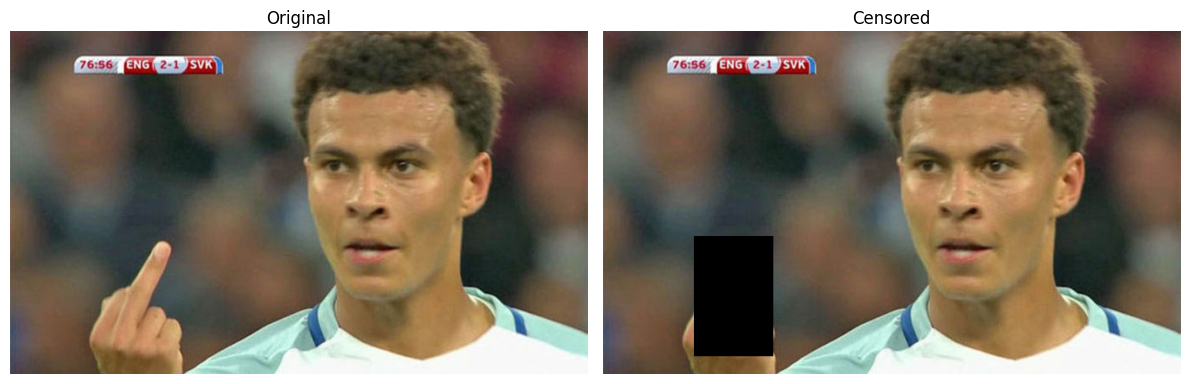

In [26]:
img_censored = img_rgb.copy()

if results.hand_landmarks:
    for i, hand_landmarks in enumerate(results.hand_landmarks):
        features = extract_features(hand_landmarks)

        rule_detected, rule_reason = is_middle_finger_rule_based(features)
        nn_detected, nn_confidence = is_middle_finger_nn(features)

        print(f"Hand {i + 1}")
        print(f"  Rule-based : {'DETECTED' if rule_detected else 'not detected'} ({rule_reason})")
        print(f"  Keras MLP  : {'DETECTED' if nn_detected else 'not detected'} (confidence {nn_confidence:.1%})")

        if rule_detected or nn_detected:
            x1, y1, x2, y2 = get_middle_finger_bbox(hand_landmarks, img_rgb.shape)
            cv2.rectangle(img_censored, (x1, y1), (x2, y2), color=(0, 0, 0), thickness=-1)
            print(f"  Censored   : rectangle ({x1},{y1}) → ({x2},{y2})")
        print()
else:
    print("No hands detected in this image.")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(img_censored)
axes[1].set_title("Censored")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## 8. Discussion

### What works well
- MediaPipe handles all the hard detection work out of the box — getting 21 accurate hand landmarks from an arbitrary photo is non-trivial, and it does it reliably without any custom training.
- The 5 extension ratios are easy to interpret: you can look at the values and immediately see which fingers are up or down.
- Having a rule-based classifier alongside the neural network is useful for debugging — if both agree, you can be more confident in the prediction.

### Limitations
- The MLP was trained on synthetic data, so it may not generalise well to unusual hand angles or proportions it hasn't seen before.
- The threshold of `0.3` was picked manually and might need adjusting for different cameras or image resolutions.
- Side-view hands are a problem — the extension ratios assume the hand is roughly facing the camera.
- MediaPipe can miss landmarks when the hand is partially hidden.

### Extending to real data
1. Download the [HaGRID dataset](https://github.com/hukenovs/hagrid) — it has a dedicated `middle_finger` class with thousands of real images.
2. Run MediaPipe on each image, call `extract_features()`, and save the results to a CSV.
3. Replace `generate_synthetic_data()` with `pd.read_csv()` — the rest of the pipeline stays the same.

### Why both classifiers tend to agree
The MLP was trained on data generated using the same rules as the rule-based classifier, so they end up with similar boundaries. On real data they would likely diverge more, since the MLP can pick up on patterns that don't fit neatly into a fixed threshold.